# Netflix Dataset Analysis

## Data Science Internship - Month 2

### Task 4: Exploratory Data Analysis on Netflix Dataset

This project analyzes the Netflix Titles dataset using Python and Exploratory Data Analysis (EDA).

The objective is to discover trends in content types, ratings, release years, countries, and genres available on Netflix.

Author: Anushree S Jambagi

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../datasets/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Dataset Overview

Before performing analysis, it is important to understand the structure of the dataset.

We examine the number of rows, columns, and available features.

In [2]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Previewing Dataset

The first few records help us understand the available attributes and content structure.

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Missing Values Analysis

Real-world datasets often contain missing values.

Identifying missing values helps determine whether cleaning or preprocessing is required.

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Handling Missing Values

Missing values in text columns are replaced with "Unknown" to maintain consistency during analysis.

In [5]:
df.fillna("Unknown", inplace=True)

df.isnull().sum().sum()

np.int64(0)

# Content Type Distribution

Netflix content is primarily categorized into Movies and TV Shows.

This analysis shows the distribution of content types available on the platform.

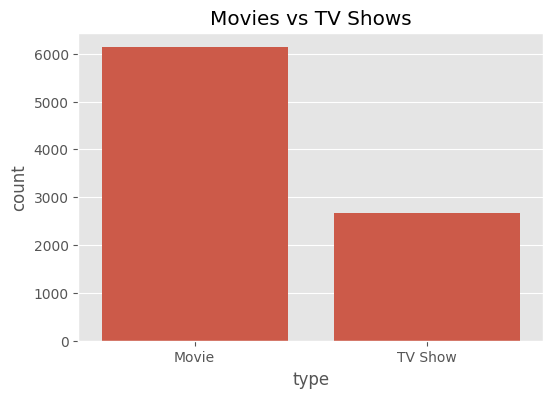

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="type",
    data=df
)

plt.title("Movies vs TV Shows")

plt.savefig(
    "../outputs/netflix_outputs/content_type_distribution.png"
)

plt.show()

## Observation

Movies represent the majority of Netflix content.

TV Shows constitute a smaller but significant portion of the catalog.

This indicates that Netflix heavily invests in movie content while maintaining a strong television portfolio.

# Ratings Distribution Analysis

Netflix content is assigned ratings based on audience suitability.

Analyzing ratings helps understand the target audience categories available on the platform.

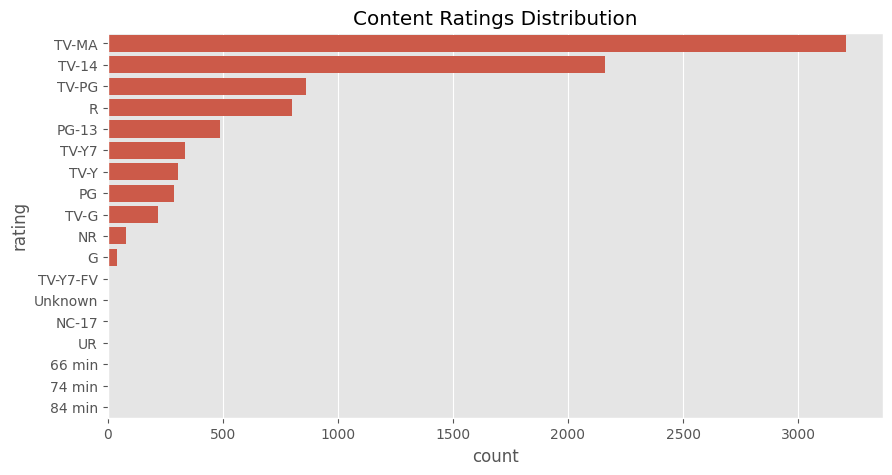

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index
)

plt.title("Content Ratings Distribution")

plt.savefig(
    "../outputs/netflix_outputs/ratings_distribution.png"
)

plt.show()

## Observation

TV-MA is the most common rating on Netflix.

The platform contains a significant amount of mature audience content, followed by TV-14 and PG-rated content.

Netflix caters to a diverse audience across different age groups.

# Top Countries Producing Netflix Content

Netflix hosts content from many countries around the world.

This analysis identifies the countries contributing the highest number of titles.

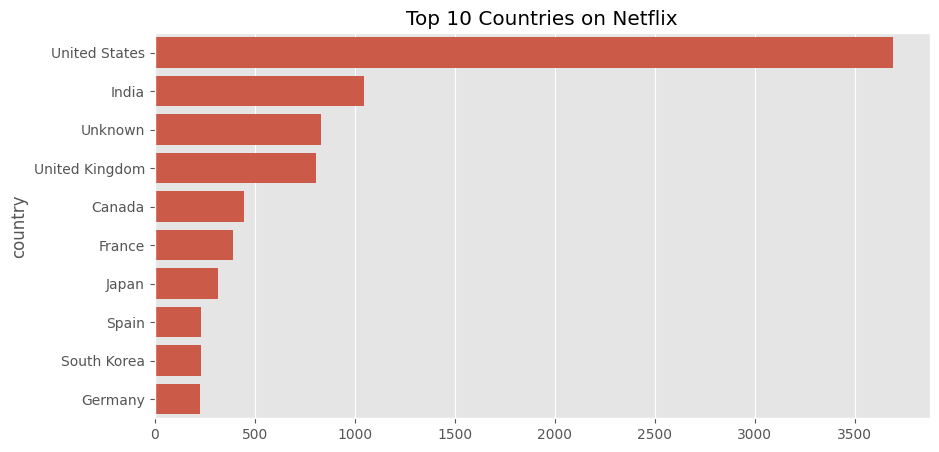

In [8]:
top_countries = (
    df["country"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries on Netflix")

plt.savefig(
    "../outputs/netflix_outputs/top_countries.png"
)

plt.show()

## Observation

The United States contributes the largest number of titles on Netflix.

Countries such as India, the United Kingdom, Canada, and Japan also contribute significantly.

This demonstrates Netflix's global content strategy.

# Release Year Analysis

Understanding release year trends helps identify periods of increased content production.

This analysis explores how Netflix content is distributed across release years.

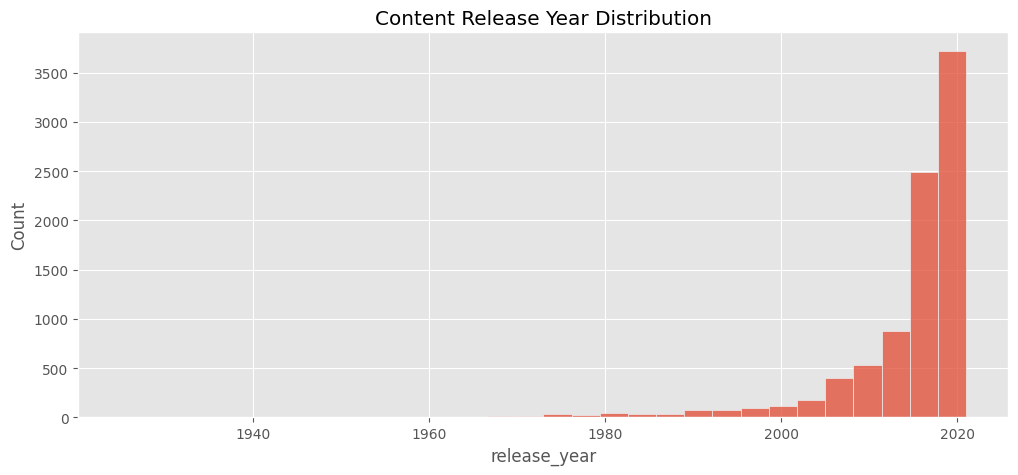

In [9]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["release_year"],
    bins=30
)

plt.title("Content Release Year Distribution")

plt.savefig(
    "../outputs/netflix_outputs/release_year_distribution.png"
)

plt.show()

## Observation

Most Netflix content originates from recent years.

A noticeable increase in content production is observed after 2010.

This reflects the rapid expansion of the streaming industry.

# Genre Analysis

Genres help categorize content based on themes and audience interests.

This analysis identifies the most common genres available on Netflix.

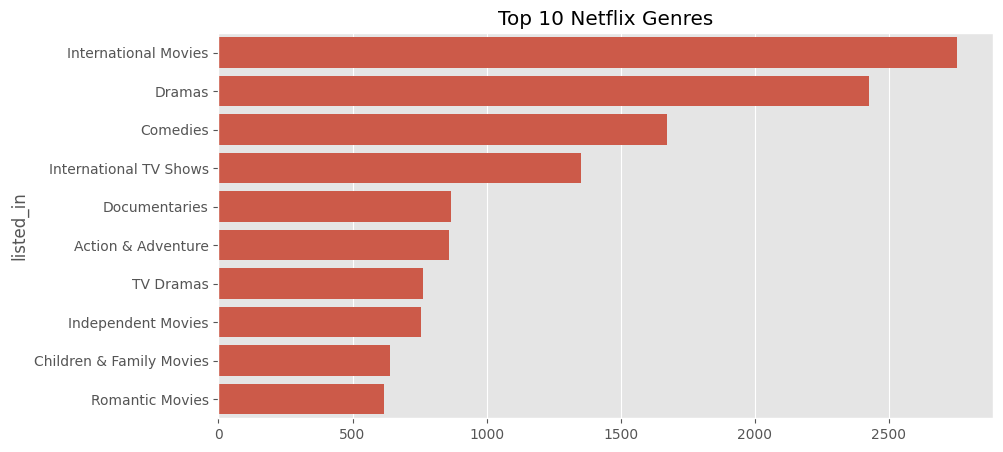

In [10]:
top_genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")

plt.savefig(
    "../outputs/netflix_outputs/top_genres.png"
)

plt.show()

## Observation

Drama, International Movies, and Comedy are among the most common genres on Netflix.

The platform offers a broad variety of content categories to serve diverse viewer interests.

Genre diversity is a major strength of Netflix's content library.

# Content Added Over Time

Netflix continuously expands its content library.

This analysis examines the number of titles added to Netflix over time.

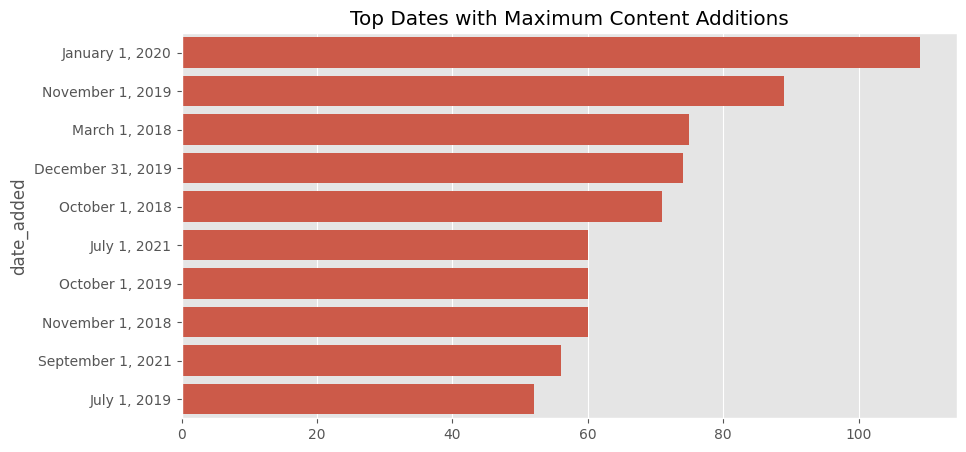

In [11]:
content_added = (
    df["date_added"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=content_added.values,
    y=content_added.index
)

plt.title("Top Dates with Maximum Content Additions")

plt.savefig(
    "../outputs/netflix_outputs/content_added_over_time.png"
)

plt.show()

## Observation

Netflix frequently adds large batches of content on specific dates.

Content additions indicate ongoing efforts to expand and refresh the platform’s catalog.

Regular updates help maintain user engagement and attract new subscribers.

# Key Business Insights

1. Movies dominate the Netflix catalog compared to TV Shows.

2. TV-MA is the most common rating, indicating strong availability of mature audience content.

3. The United States contributes the largest amount of content on Netflix.

4. Content production increased significantly after 2010.

5. Drama, International Movies, and Comedy are among the most popular genres.

6. Netflix maintains a globally diverse content library to appeal to international audiences.

# Conclusion

This Netflix Dataset Analysis project explored content trends using Exploratory Data Analysis (EDA).

The analysis revealed key insights regarding content type distribution, ratings, countries, genres, and release year patterns.

Netflix maintains a diverse catalog consisting of movies and television shows from multiple countries and genres.

The findings highlight Netflix's global reach, content diversity, and continued investment in expanding its entertainment offerings.

# End of Project

Project Completed Successfully

Dataset:
Netflix Titles Dataset

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

Author:
Anushree S Jambagi

Internship:
Data Science Internship – Month 2

Task:
Netflix Dataset Analysis using Exploratory Data Analysis (EDA)